# Clasificador Reclamo o Requerimientos

## 1. Entendimiento del negocio

__Objetivo:__ Clasificar una solicitud atendida por el área de operaciones como un reclamo de un requerimiento. Solicitud que fue ingresada a través de un crm por un canal: call center, agencias presenciales, libro de reclamaciones

__Problema a resolver para negocio:__ No hay manera de identificar las solicitudes de reclamos o requerimientos, ya que estos son ingresadas de manera manual, y muchas veces son clasificadas de manera incorrecta por los asesores. Asimismo, al ser reclamos, un indicador sensible que se reporta a SBS, es necesario clasificarlos bien. El problema es que este método fue construido hace muchos años, pero se observó que en el tiempo ha ido reduciendo su exactitud. Se busca un método para mantener la precisión en el tiempo.

__Situación Actual (As is):__ Los reclamos y requerimientos son clasificados por un sistema basado en reglas. Se asignan pesos a ciertas palabras relacionadas a reclamos y requerimientos respectivamente. Si un comentario del reclamo tiene más palabras relacionadas a reclamos, se le asigna esa identificación.

__To be:__ Se propone un modelo de machine learning, ya que estos son caracterízados por realizar predicciones en datos nuevos.

__Posible Modelo:__ TF-IDF + Logistic Regression 

__Etapas Tentativas (alto nivel):__
Entender el dataset y EDA
Preprocesamiento (minusculas, comas, puntos, stopwords)
Tokenizacion
TF-IDF 
Regresion logistica 
Porque funciona muy bien en espacios de alta dimensión como TF-IDF, es rápida, interpretable y suele ser una excelente línea base para clasificación de texto. 
Entrenamiento
Validacion (metricas)
Otros modelos (comparacion)
Interpretabilidad de coeficientes
Simulacion en produccion (OOT)

__Consideraciones:__ El objetivo del proyecto es demostrar la metodología de construcción de un clasificador de texto para diferenciar solicitudes de distinta naturaleza. Aunque el caso utiliza información del sector salud, el flujo de trabajo (preprocesamiento, TF-IDF, entrenamiento, validación y despliegue) es directamente aplicable a escenarios similares en banca.

## 2. Comprensión de los datos

In [1]:
!pip install openpyxl

In [2]:
import pandas as pd

In [3]:
#pd.set_option('display.max_columns',None)
#pd.set_option('display.max_rows',None)
#pd.set_option('display.max_colwidth',None)

In [4]:
import pandas as pd
ruta_input="C:/Users/stali/Documents/proyecto_machine_learning/clasificador_reclamos_requerimientos/data/BD_CONSOLIDADA.xlsx"
df=pd.read_excel(ruta_input,sheet_name='BD')
display(df.head())

,SOURCE,EMPRESA,CLASIFICACION_GENERAL,SUBMOTIVO,FECHA,ANIO,MESANIO,COMENTARIO,FINAL,ALEATORIO
0,ATENCION PLATAFORMA,PACIFICO,REQUERIMIENTO,Autorizacion Examenes,2023-03-16 17:06:21,2023,202303,* Se solicita pertinencia a Audt Oncológica d...,REQUERIMIENTO,0.999995
1,ENCUESTAS,SANNA EL GOLF,ENCUESTAS,DETRACTORES,2022-09-01 18:56:00,2022,202209,"Sus sistemas no son buenos, las cita están mal...",RECLAMO,0.999823
2,ATENCION PLATAFORMA,PACIFICO,REQUERIMIENTO,Procedimiento Atencion Clinica,2023-03-30 15:12:49,2023,202303,Asegurado refiere que tiene indicación de exam...,REQUERIMIENTO,0.999816
3,ATENCION PLATAFORMA,PACIFICO,CONSULTA,Cobertura,2023-03-29 18:53:31,2023,202303,Se informa asegurada su hijo CARLOS LEONARDO O...,REQUERIMIENTO,0.999730
4,RECLAMOS,PACIFICO,RECLAMOS,Rechazo total/parcial de cobertura,2022-09-19 21:40:08,2022,202209,"Siendo las 2:37 am ingresé a emergencia, me at...",RECLAMO,0.999685


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25857 entries, 0 to 25856
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   SOURCE                 25857 non-null  str           
 1   EMPRESA                25857 non-null  str           
 2   CLASIFICACION_GENERAL  25857 non-null  str           
 3   SUBMOTIVO              25591 non-null  str           
 4   FECHA                  25857 non-null  datetime64[us]
 5   ANIO                   25857 non-null  int64         
 6   MESANIO                25857 non-null  int64         
 7   COMENTARIO             25856 non-null  str           
 8   FINAL                  25857 non-null  str           
 9   ALEATORIO              25857 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(6)
memory usage: 2.0 MB


In [6]:
df_group=df.groupby('FINAL').size().reset_index(name='Cantidad')
df_group['Participacion']=df_group['Cantidad']/df_group['Cantidad'].sum()
display(df_group)

,FINAL,Cantidad,Participacion
0,RECLAMO,13992,0.54113
1,REQUERIMIENTO,11865,0.45887


## 3. EDA: Exploratory Data Analysis

#### Distribucion de longitud de comentarios
__Conclusion:__ 
* Los comentarios de requerimientos alcanzan su pico en 50 caracteres luego disminuyen
* Los comentarios de reclamos tienen tamaño constante hasta 1000 caracteres
* Se recomienda que para el entrenamiento se filtren los comentarios mayores a 1500 caracteres

In [7]:
df['longitud_comentario']=df['COMENTARIO'].str.len()
display(df.head())

,SOURCE,EMPRESA,CLASIFICACION_GENERAL,SUBMOTIVO,FECHA,ANIO,MESANIO,COMENTARIO,FINAL,ALEATORIO,longitud_comentario
0,ATENCION PLATAFORMA,PACIFICO,REQUERIMIENTO,Autorizacion Examenes,2023-03-16 17:06:21,2023,202303,* Se solicita pertinencia a Audt Oncológica d...,REQUERIMIENTO,0.999995,176.0
1,ENCUESTAS,SANNA EL GOLF,ENCUESTAS,DETRACTORES,2022-09-01 18:56:00,2022,202209,"Sus sistemas no son buenos, las cita están mal...",RECLAMO,0.999823,84.0
2,ATENCION PLATAFORMA,PACIFICO,REQUERIMIENTO,Procedimiento Atencion Clinica,2023-03-30 15:12:49,2023,202303,Asegurado refiere que tiene indicación de exam...,REQUERIMIENTO,0.999816,173.0
3,ATENCION PLATAFORMA,PACIFICO,CONSULTA,Cobertura,2023-03-29 18:53:31,2023,202303,Se informa asegurada su hijo CARLOS LEONARDO O...,REQUERIMIENTO,0.999730,177.0
4,RECLAMOS,PACIFICO,RECLAMOS,Rechazo total/parcial de cobertura,2022-09-19 21:40:08,2022,202209,"Siendo las 2:37 am ingresé a emergencia, me at...",RECLAMO,0.999685,971.0


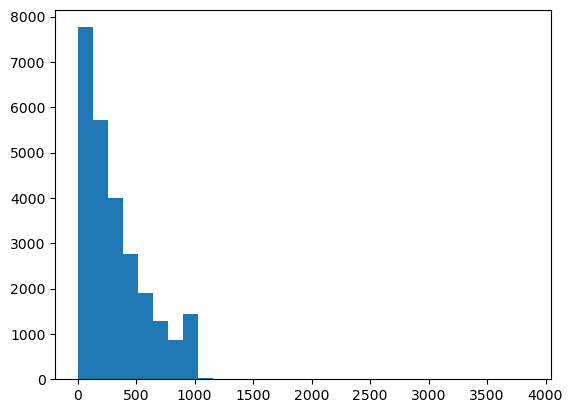

In [8]:
import matplotlib.pyplot as plt
plt.hist(df['longitud_comentario'],bins=30)
plt.show()

In [9]:
#agregar columna para ver la cantida de palabras mayores a 1500 caracteres
df['rango_longitud_comentarios']=df['longitud_comentario'].apply(lambda x: '0. Null' if pd.isna(x)
                                                                 else '1. 0-1500' if x<=1500 
                                                                 else '2. >1500')
df.groupby(['rango_longitud_comentarios']).size().reset_index(name='Cantidad')

,rango_longitud_comentarios,Cantidad
0,0. Null,1
1,1. 0-1500,25835
2,2. >1500,21


In [10]:
#display(df[df['rango_longitud_comentarios']=='2. >1500'])

In [11]:
#visualizar longitud por reclamo y requerimiento

In [12]:
pd.reset_option('display.max_colwidth')

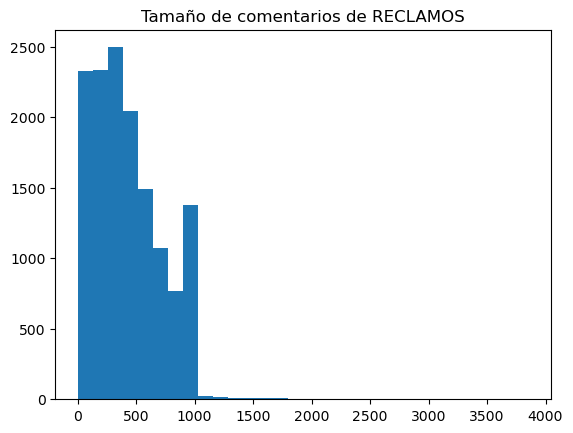

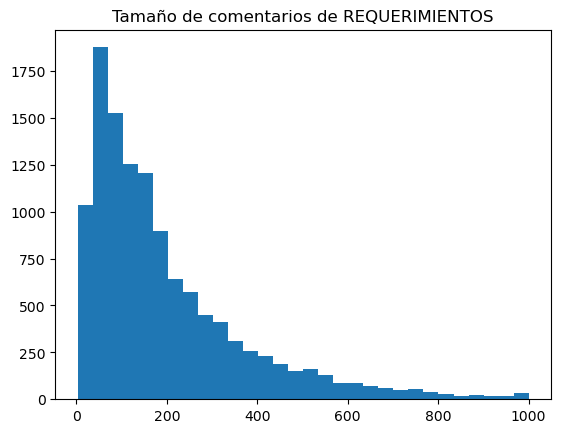

In [13]:
df_rec=df[df['FINAL']=='RECLAMO']
df_req=df[df['FINAL']=='REQUERIMIENTO']

plt.hist(df_rec['longitud_comentario'],bins=30)
plt.title('Tamaño de comentarios de RECLAMOS')
plt.show()
plt.hist(df_req['longitud_comentario'],bins=30)
plt.title('Tamaño de comentarios de REQUERIMIENTOS')
plt.show()

### Nube de palabras
__Conclusiones:__
* Los reclamos tienen palabras reclamos a: reclamo, cobro, atencion, pago
* Los requerimientos tienen: indica, informa, asegurado

In [14]:
!pip install wordcloud

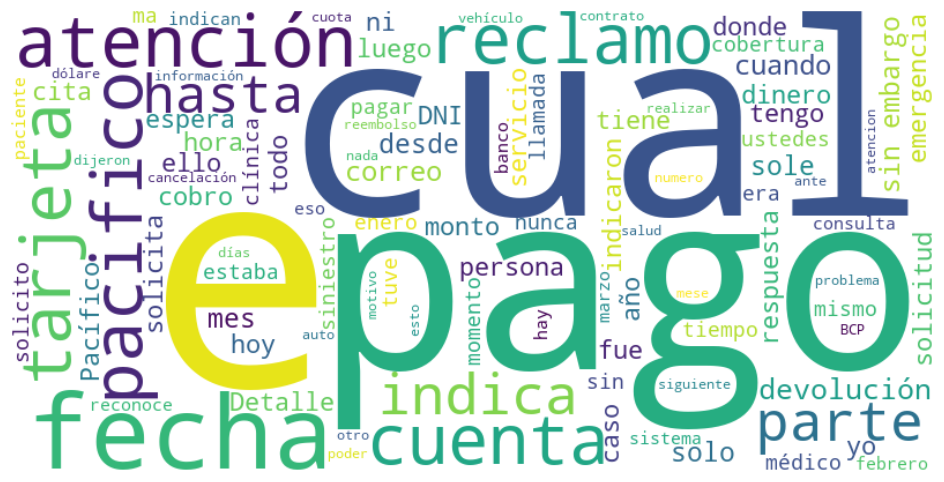

In [15]:
from wordcloud import WordCloud
palabras_vacias = {
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 
    'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 
    'sus', 'este', 'le', 'ya', 'o', 'esta', 'me', 'si', 'nos', 'bien', 'mi','seguro','poliza','póliza','dia','día',
    'Cliente','cliente','porque'
}
nube = WordCloud(
    width=800,               # Ancho de la imagen
    height=400,              # Alto de la imagen
    background_color='white',# Color de fondo
    stopwords=palabras_vacias,# Filtro de palabras creado
    colormap='viridis',      # Paleta de colores (puedes usar 'plasma', 'inferno', 'coolwarm')
    max_words=100            # Límite máximo de palabras a mostrar
).generate(" ".join(df_rec['COMENTARIO'].dropna().astype(str)))

# 5. Desplegar el gráfico usando Matplotlib
plt.figure(figsize=(12, 6))
plt.imshow(nube, interpolation='bilinear')
plt.axis("off")  # Oculta los ejes numéricos del gráfico
plt.show()

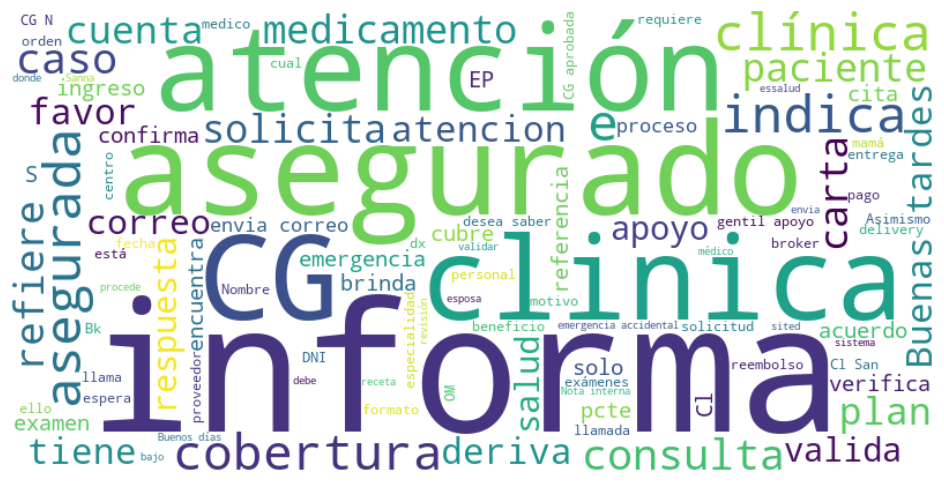

In [16]:
from wordcloud import WordCloud
palabras_vacias = {
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 
    'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 
    'sus', 'este', 'le', 'ya', 'o', 'esta', 'me', 'si', 'nos', 'bien', 'mi','seguro','poliza','póliza','dia','día',
    'Cliente','cliente','porque'
}
nube = WordCloud(
    width=800,               # Ancho de la imagen
    height=400,              # Alto de la imagen
    background_color='white',# Color de fondo
    stopwords=palabras_vacias,# Filtro de palabras creado
    colormap='viridis',      # Paleta de colores (puedes usar 'plasma', 'inferno', 'coolwarm')
    max_words=100            # Límite máximo de palabras a mostrar
).generate(" ".join(df_req['COMENTARIO'].dropna().astype(str)))

# 5. Desplegar el gráfico usando Matplotlib
plt.figure(figsize=(12, 6))
plt.imshow(nube, interpolation='bilinear')
plt.axis("off")  # Oculta los ejes numéricos del gráfico
plt.show()

### Ranking de palabras mas frecuentes 

In [17]:
#importa funcion que vectoriza las palabras y las cuenta
from sklearn.feature_extraction.text import CountVectorizer

In [18]:
#inicializamos
vectorizer = CountVectorizer()

#quitamos nulos
df_rec_sin_nulos=df_rec[ df_rec['COMENTARIO'].notna()]
#display(df_rec_sin_nulos.head())

#obtiene Matriz Dispersa, luego de entrenar y transformar a 0,1
X=vectorizer.fit_transform(df_rec_sin_nulos['COMENTARIO'])
#print(X)

#sumar la cantidad de veces que una palabra salio en todos los comentarios, axis=0: vertical/columna
#obs: se guarda como matriz matemática multidimension (una matriz fila de NumPy).
frecuencias = X.sum(axis=0) 

#lista de palabras
palabras = vectorizer.get_feature_names_out()

#construir tabla de frecuencias
df_rec_freq_palabras=pd.DataFrame(
    {'palabra':palabras,
    'frecuencia':frecuencias.A1} # A1 "aplana" esa matriz y la convierte en un vector simple de una sola dimensión (una lista normal de números)
)
print("Lista de palabras mas frecuentes en Reclamos, sin limpiar")
df_rec_freq_palabras.sort_values('frecuencia',ascending=False).head(50)

Lista de palabras mas frecuentes en Reclamos, sin limpiar


,palabra,frecuencia
18343,de,57398
33704,que,43302
26902,la,36136
20736,el,34400
29849,no,21617
28418,me,18859
21079,en,17687
32504,por,17020
36500,se,16152
16561,con,13688


In [19]:
#inicializamos
vectorizer=CountVectorizer()

#quitamos nulos
df_req_sin_nulos=df_req[df_req['COMENTARIO'].notna()]
#display(df_req_sin_nulos.head())

#obtiene Matriz Dispersa, luego de entrenar y transformar a 0,1
X=vectorizer.fit_transform(df_req_sin_nulos['COMENTARIO'])

#sumar la cantidad de veces que una palabra salio en todos los comentarios, axis=0: vertical/columna
#obs: se guarda como matriz matemática multidimension (una matriz fila de NumPy).
frecuencia=X.sum(axis=0)

#lista de palabras
palabras=vectorizer.get_feature_names_out()

#construir tabla de frecuencias
df_req_freq_palabras=pd.DataFrame({
    'palabras':palabras,
    'cantidad':frecuencia.A1
})

df_req_freq_palabras.sort_values('cantidad',ascending=False).head(50)

,palabras,cantidad
6926,de,23246
16562,se,21128
15151,que,10876
11362,la,9634
7918,el,7084
8113,en,6799
13919,para,6491
5870,con,5862
10628,informa,5485
13139,no,5342


## 4. Preprocesamiento

### Convertir a Minusculas, quitar numeros signos, limpiar espacio

In [20]:
df_model=df.copy()
#display(df_model.head())

In [2]:
import sys
sys.path.append('../scr')
from funciones import limpiar_comentario

In [21]:
#pd.set_option('display.max_colwidth',None)
pd.reset_option('display.max_colwidth')

In [22]:
#transformar
df_model['COMENTARIO_limpio']=df_model['COMENTARIO'].apply(limpiar_comentario)
#display(df_model.head())

### Eliminar Stop Words

In [23]:
stop_words = {
    #detectados segun ranking
    'la','el','lo','al','los','las','le','ella',
   'de', 'se','que','en','por','su','del','una','ya','es'
    ,'dia','fecha','si','esta',
    'con','para',
    'ha',
    'un',
    #añadidos por sugerencia de ia
    'asegurado','asegurada',

    'mi', 'mis', 'me', 'nos', 'te', 'le', 'les', 'yo', 'usted', 'ustedes', 'este', 'esta', 'estos', 'esta','a'
}

In [24]:
!pip install nltk

In [25]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\stali\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
#funcion para cada stop_words(para cada comentario)
from funciones import quitar_stop_words

In [27]:
df_model['COMENTARIO_limpio_sin_stopwords']=df_model['COMENTARIO_limpio'].apply(lambda x: quitar_stop_words(x,stop_words))
display(df_model.head())

,SOURCE,EMPRESA,CLASIFICACION_GENERAL,SUBMOTIVO,FECHA,ANIO,MESANIO,COMENTARIO,FINAL,ALEATORIO,longitud_comentario,rango_longitud_comentarios,COMENTARIO_limpio,COMENTARIO_limpio_sin_stopwords
0,ATENCION PLATAFORMA,PACIFICO,REQUERIMIENTO,Autorizacion Examenes,2023-03-16 17:06:21,2023,202303,* Se solicita pertinencia a Audt Oncológica d...,REQUERIMIENTO,0.999995,176.0,1. 0-1500,se solicita pertinencia a audt oncologica de l...,solicita pertinencia audt oncologica laborator...
1,ENCUESTAS,SANNA EL GOLF,ENCUESTAS,DETRACTORES,2022-09-01 18:56:00,2022,202209,"Sus sistemas no son buenos, las cita están mal...",RECLAMO,0.999823,84.0,1. 0-1500,sus sistemas no son buenos las cita estan mal ...,sus sistemas no son buenos cita estan mal prog...
2,ATENCION PLATAFORMA,PACIFICO,REQUERIMIENTO,Procedimiento Atencion Clinica,2023-03-30 15:12:49,2023,202303,Asegurado refiere que tiene indicación de exam...,REQUERIMIENTO,0.999816,173.0,1. 0-1500,asegurado refiere que tiene indicacion de exam...,refiere tiene indicacion examen tomografia y c...
3,ATENCION PLATAFORMA,PACIFICO,CONSULTA,Cobertura,2023-03-29 18:53:31,2023,202303,Se informa asegurada su hijo CARLOS LEONARDO O...,REQUERIMIENTO,0.999730,177.0,1. 0-1500,se informa asegurada su hijo carlos leonardo o...,informa hijo carlos leonardo oviedo elias vig ...
4,RECLAMOS,PACIFICO,RECLAMOS,Rechazo total/parcial de cobertura,2022-09-19 21:40:08,2022,202209,"Siendo las 2:37 am ingresé a emergencia, me at...",RECLAMO,0.999685,971.0,1. 0-1500,siendo las am ingrese a emergencia me atendio ...,siendo am ingrese emergencia atendio dr cuadro...


In [28]:
#revisar nuevo listado de palabras
from sklearn.feature_extraction.text import CountVectorizer

#inicializamos
vectorizer=CountVectorizer()

#quitamos nulos
df_model_sin_nulos=df_model[df_model['COMENTARIO_limpio_sin_stopwords'].notna()]

#obtiene Matriz Dispersa, luego de entrenar y transformar a 0,1
X=vectorizer.fit_transform(df_model_sin_nulos['COMENTARIO_limpio_sin_stopwords'])

#sumar
frecuencias=X.sum(axis=0)

#lista de palabras
palabras=vectorizer.get_feature_names_out()

#construir tabla de frecuencias
df_model_frecuencias=pd.DataFrame({
    'palabra':palabras,
    'cantidad':frecuencias.A1})

print("Lista de palabras mas frecuentes en modelo, limpio")

df_model_frecuencias.sort_values('cantidad',ascending=False).head(40)

Lista de palabras mas frecuentes en modelo, limpio


,palabra,cantidad
25226,no,26881
33731,seguro,8828
3655,atencion,6672
28637,poliza,6137
19676,informa,5764
7318,clinica,5528
26753,pacifico,5502
7242,cliente,4509
19418,indica,4329
10046,cual,4168


In [30]:
#agregamos
#observamos comentarios com menos de 5 palabras
#se observa que incluso con 1 palabra efectiva (sin stopwords) te da indicios de una buena preduccion

In [31]:
df_model['longitud_comentario_limpio_final']=df_model['COMENTARIO_limpio_sin_stopwords'].str.len()

In [40]:
import re
df_model['palabras_comentario_limpio_final']=df_model['COMENTARIO_limpio_sin_stopwords'].str.count(' ')+1

In [51]:
#display(df_model[df_model['palabras_comentario_limpio_final']<=1].head(10))

In [52]:
#pd.set_option('display.max_rows',None)
#df_model[df_model['palabras_comentario_limpio_final']<=1].groupby('COMENTARIO_limpio_sin_stopwords').size().reset_index(name='Cantidad').sort_values('Cantidad',ascending=False)

## 5. Definir oot

In [29]:
df_model['flg_oot']=df_model.apply(lambda x: 1 if x['FINAL']=='RECLAMO' and x['ANIO']==2023
                                   else 1 if x['FINAL']=='REQUERIMIENTO' and x['MESANIO']==202304
                                   else 0, axis=1)
#display(df_model.head())
#df_model[(df_model['flg_oot']==1) & (df_model['FINAL']=='RECLAMO')].groupby('ANIO').size().reset_index(name='cantidad')

In [ ]:
#df_oot.to_excel("C:/Users/stali/Documents/proyecto_machine_learning/clasificador_reclamos_requerimientos/bd_oot_reclamo_requerimiento")

## 5. Definir data train, test, validacion

In [53]:
df_train=df_model[df_model['flg_oot']==0]

In [54]:
from sklearn.model_selection import train_test_split

#sintaxis train_test_split(x,y,train_size=,random_state=)

X_train, X_test, Y_train, Y_test =train_test_split(df_train['COMENTARIO_limpio_sin_stopwords'],df_train['FINAL'],train_size=0.8,random_state=42)

## 6. Ingenierias de variables: TF-IDF

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

#inicializamos
tf_idf_model=TfidfVectorizer(
     # El texto ya fue convertido a minúsculas durante la limpieza
    lowercase=False,
    # Ignora palabras que aparecen en menos de 3 comentarios
    # (errores ortográficos o palabras demasiado raras)
    min_df=3,
    # Ignora palabras presentes en más del 95% de los comentarios
    # porque casi no ayudan a diferenciar clases
    max_df=0.95,
    # Considera palabras individuales y pares de palabras
    # Ejemplo:
    # "cancelar"
    # "quiero cancelar"
    ngram_range=(1,2),

    # Reduce el impacto de palabras repetidas muchas veces
    sublinear_tf=True)

#transformar y entrenar a train
x_train_tf_idf=tf_idf_model.fit_transform(X_train)

#transformar a test
x_test_tf_idf=tf_idf_model.transform(X_test)


In [58]:
# ----------------------------------------------------------
# Información general
# ----------------------------------------------------------
print("Cantidad de documentos Train :", x_train_tf_idf.shape[0])
print("Cantidad de palabras únicas  :", x_train_tf_idf.shape[1])

Cantidad de documentos Train : 17669
Cantidad de palabras únicas  : 38346


In [59]:
# ----------------------------------------------------------
# Mostrar las primeras palabras del vocabulario
# ----------------------------------------------------------
print("\nPrimeras 30 palabras del vocabulario:\n")

print(tf_idf_model.get_feature_names_out()[:30])


Primeras 30 palabras del vocabulario:

['aaron' 'aasegurada' 'aass' 'aass cambio' 'aass consulta' 'aauth'
 'aauth req' 'aauth reqad' 'abad' 'abajo' 'abajo respuesta' 'abandona'
 'abandona chat' 'abandona conversacion' 'abandonada' 'abandonado'
 'abandono' 'abanto' 'abasto' 'abc' 'abdomen' 'abdomen completa'
 'abdominal' 'abdominales' 'abel' 'abierta' 'abiertas' 'abierto'
 'abierto bajo' 'abierto mismo']


In [61]:
# ----------------------------------------------------------
# Cantidad total de palabras aprendidas
# ----------------------------------------------------------
print("\nTotal de palabras:", len(tf_idf_model.get_feature_names_out()))


Total de palabras: 38346


In [63]:
import joblib

# Guardar el vectorizador
joblib.dump(tf_idf_model, "tf_idf_model.pkl")

['tf_idf_model.pkl']

## 7. Modelo Base: Entrenar con regresión logistica

In [64]:
from sklearn.linear_model import LogisticRegression

In [65]:
#inicializamos modelo
reg_log_model=LogisticRegression(
    #semilla
    random_state=42,
    #maximo de iteraciones
    max_iter=1000)


In [66]:
#entrenar modelo
reg_log_model.fit(x_train_tf_idf,Y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [111]:
import joblib

# Guardar el vectorizador
joblib.dump(reg_log_model, "reg_log_model.pkl")

['reg_log_model.pkl']

## 8. Validación

In [67]:
Y_predict=reg_log_model.predict(x_test_tf_idf)
Y_predict_proba=reg_log_model.predict_proba(x_test_tf_idf)

In [85]:
#exportar resultados
df_resultados_test=pd.DataFrame({
    #'Comentario_real':,
    'Comentario_limpio':X_test.values,
    'Clasificion_real':Y_test.values,
    'Prediccion':Y_predict,
    'Prob_reclamo':Y_predict_proba[:,0],
    'Prob_requerimiento':Y_predict_proba[:,1],
    'Prob_prediccion':Y_predict_proba.max(axis=1)
}
)

In [86]:
ruta_output_test="C:/Users/stali/Documents/proyecto_machine_learning/clasificador_reclamos_requerimientos/resultados/resultados_test_prediccion.xlsx"
df_resultados_test.to_excel(ruta_output_test)

In [89]:
#display(df_resultados_test.head())
df_resultados_test['rango_prob_prediccion']=df_resultados_test['Prob_prediccion'].apply(lambda x: 
                                                                                            '1. 0-20%' if x<0.2 
                                                                                        else '2. 21%-40%' if x<0.4 
                                                                                        else '3. 41%-60%' if x<0.6 
                                                                                        else '4. 61%-80%' if x<0.8 
                                                                                        else '5. 81%-90%' if x<0.9
                                                                                        else '6. 91%-100%')

In [90]:
df_resultados_test.groupby('rango_prob_prediccion').size().reset_index(name='cantidad').sort_values('cantidad',ascending=False)

,rango_prob_prediccion,cantidad
3,6. 91%-100%,3282
2,5. 81%-90%,676
1,4. 61%-80%,382
0,3. 41%-60%,78


In [74]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [75]:
accuracy=accuracy_score(Y_test,Y_predict)
precision=precision_score(Y_test,Y_predict,average='weighted')
recall_score=recall_score(Y_test,Y_predict,average='weighted')
f1=f1_score(Y_test,Y_predict,average='weighted')

print(f"El accuracy es: {accuracy}")
print(f"La precision es: {precision}")
print(f"El recall_score es: {recall_score}")
print(f"El f1 es: {f1}")

El accuracy es: 0.9891353553644183
La precision es: 0.9891428647291994
El recall_score es: 0.9891353553644183
El f1 es: 0.9891340267369422


In [80]:
#reporte completa por clase
print(classification_report(Y_test, Y_predict))

               precision    recall  f1-score   support

      RECLAMO       0.99      0.99      0.99      2323
REQUERIMIENTO       0.99      0.99      0.99      2095

     accuracy                           0.99      4418
    macro avg       0.99      0.99      0.99      4418
 weighted avg       0.99      0.99      0.99      4418



In [81]:
from sklearn.metrics import confusion_matrix
print(reg_log_model.classes_)
print(confusion_matrix(Y_test, Y_predict))

['RECLAMO' 'REQUERIMIENTO']
[[2304   19]
 [  29 2066]]


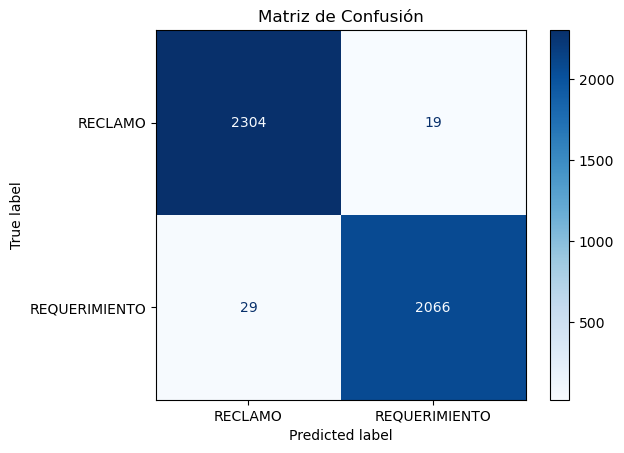

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    Y_test,
    Y_predict,
    cmap="Blues"
)

plt.title("Matriz de Confusión")
plt.show()

In [94]:
df_resultados_test['flg_prediccion']=df_resultados_test.apply(lambda x:
                                                              1 if x['Prediccion']==x['Clasificion_real']
                                                                       else 0, axis=1)

In [96]:
#accuracy_p=df_resultados_test['flg_prediccion'].mean()
#print(accuracy_p)

0.9891353553644183


In [107]:
total_test=len(df_resultados_test)

In [110]:
#quedarnos con un rango que sea seguro pero confiable: df_resultados_test
rangos=[0.95, 0.90, 0.85, 0.80, 0.7, 0.6, 0.55]
accuracy_rangos=[]
cantidad_rangos=[]
no_cubiertos=[]
porc_no_cubiertos=[]
for umbral in rangos:
    df_umbral=df_resultados_test[df_resultados_test['Prob_prediccion']>=umbral]
    accuracy=df_umbral['flg_prediccion'].mean()
    accuracy_rangos.append(accuracy)
    cantidad_rangos.append(len(df_umbral))
    no_cubiertos.append(total_test-len(df_umbral))
    porc_no_cubiertos.append((total_test-len(df_umbral))/total_test)
    
resumen_umbrales=pd.DataFrame({
    'umbral': rangos,
    "Casos cubiertos": cantidad_rangos,
    "Casos No Cubiertos": no_cubiertos,
    "Porcentaje No Cubiertos":porc_no_cubiertos,
    'accuracy':accuracy_rangos
})

display(resumen_umbrales)

,umbral,Casos cubiertos,Casos No Cubiertos,Porcentaje No Cubiertos,accuracy
0,0.95,2324,2094,0.473970,1.000000
1,0.90,3282,1136,0.257130,1.000000
2,0.85,3729,689,0.155953,0.999732
3,0.80,3958,460,0.104120,0.998737
4,0.70,4213,205,0.046401,0.997626
5,0.60,4340,78,0.017655,0.994931
6,0.55,4373,45,0.010186,0.992682


## 9. Otros Modelos

## 10. OOT: Out Of Time